Dataset successfully loaded using Seaborn!


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


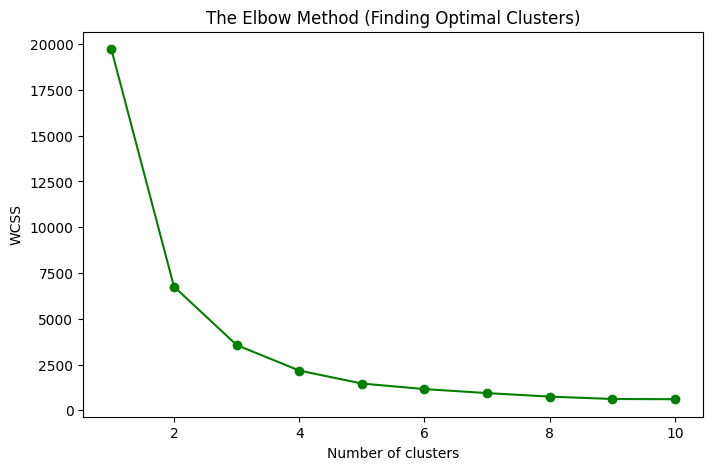

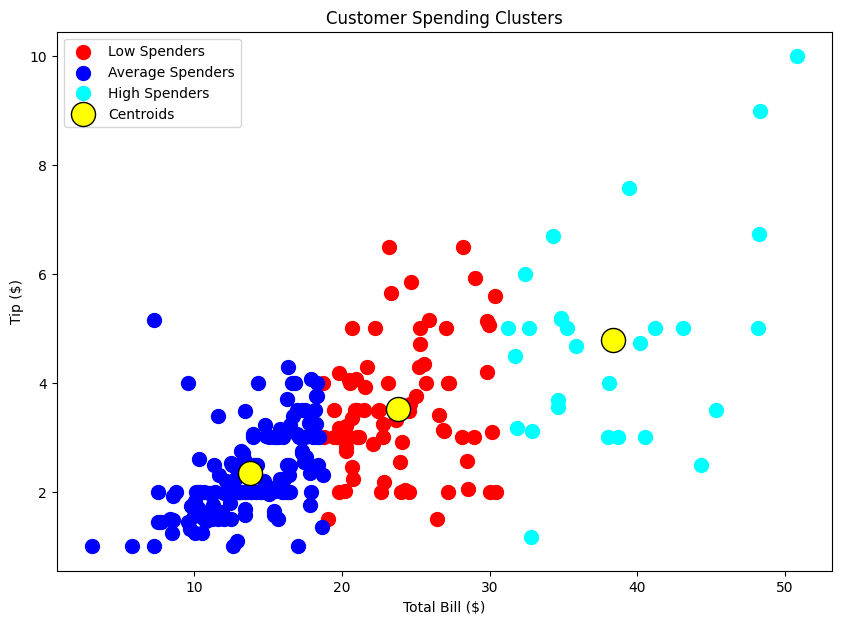

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df_mall = sns.load_dataset('tips')

print("Dataset successfully loaded using Seaborn!")
display(df_mall.head())

X_mall = df_mall[['total_bill', 'tip']].values

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_mall)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o', color='green')
plt.title('The Elbow Method (Finding Optimal Clusters)')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_mall)

plt.figure(figsize=(10,7))
plt.scatter(X_mall[y_kmeans == 0, 0], X_mall[y_kmeans == 0, 1], s=100, c='red', label='Low Spenders')
plt.scatter(X_mall[y_kmeans == 1, 0], X_mall[y_kmeans == 1, 1], s=100, c='blue', label='Average Spenders')
plt.scatter(X_mall[y_kmeans == 2, 0], X_mall[y_kmeans == 2, 1], s=100, c='cyan', label='High Spenders')

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='yellow', label='Centroids', edgecolors='black')
plt.title('Customer Spending Clusters')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.legend()
plt.show()